<a href="https://colab.research.google.com/github/sangitaGIT011/Myproj/blob/main/GOLD_PRICE_ANALYSIS_AND_PREDICTION_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         Date       Close        High         Low        Open    Volume  \
0  29-01-2016  106.949997  107.000000  106.260002  106.610001   8098700   
1  01-02-2016  108.050003  108.150002  107.529999  107.540001  10471800   
2  02-02-2016  108.089996  108.180000  107.349998  107.919998   6656000   
3  03-02-2016  109.250000  109.580002  107.900002  107.910004  15785200   
4  04-02-2016  110.570000  110.699997  109.919998  110.449997  13213700   

    Adj Close  Daily_Return  MA_20  MA_50  MA_200  Volatility_20  Year  Month  \
0  106.949997           NaN    NaN    NaN     NaN            NaN  2016      1   
1  108.050003      1.028524    NaN    NaN     NaN            NaN  2016      2   
2  108.089996      0.037014    NaN    NaN     NaN            NaN  2016      2   
3  109.250000      1.073183    NaN    NaN     NaN            NaN  2016      2   
4  110.570000      1.208238    NaN    NaN     NaN            NaN  2016      2   

   Day_of_Week  Quarter  
0            4        1  
1         

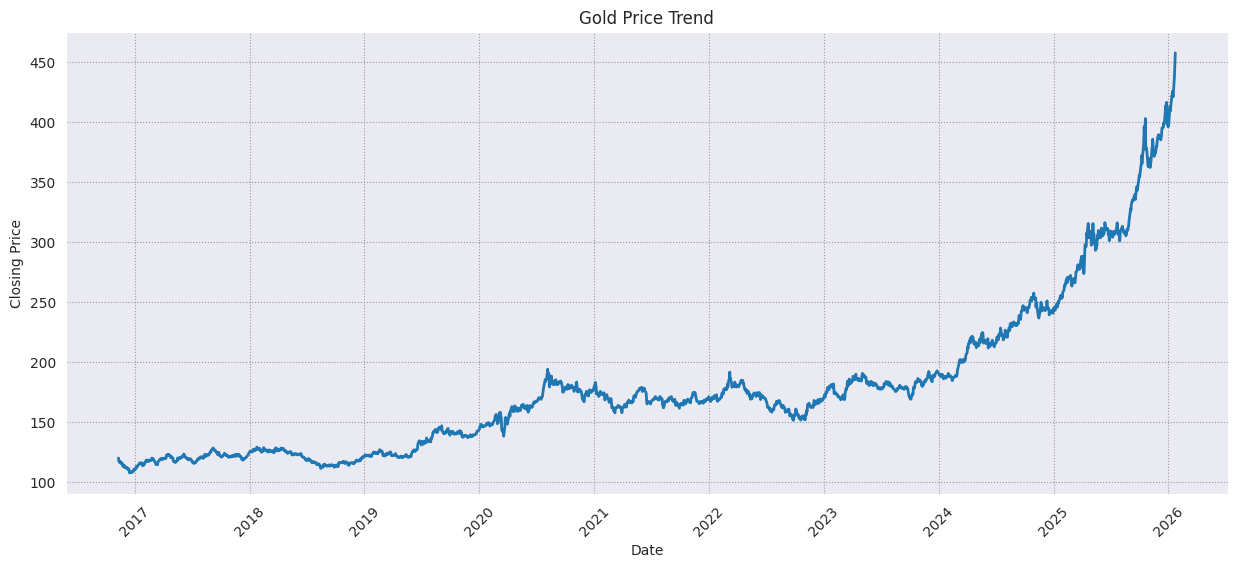

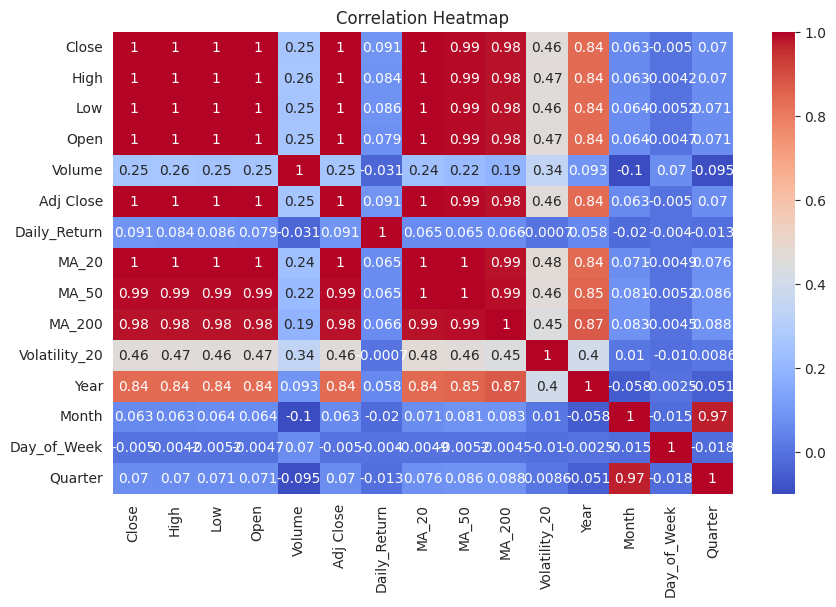


Predicted Gold Prices

   Actual Price  Predicted Price
0    182.039993       181.955599
1    115.669998       115.689999
2    214.210007       214.259400
3    115.849998       115.717099
4    172.490005       171.853900
5    164.660004       165.065299
6    191.509995       191.342000
7    220.929993       220.620300
8    243.440002       243.717002
9    188.750000       188.894598

Model Performance
R2 Score : 0.9997945492661313
Mean Squared Error : 0.8707042431841918


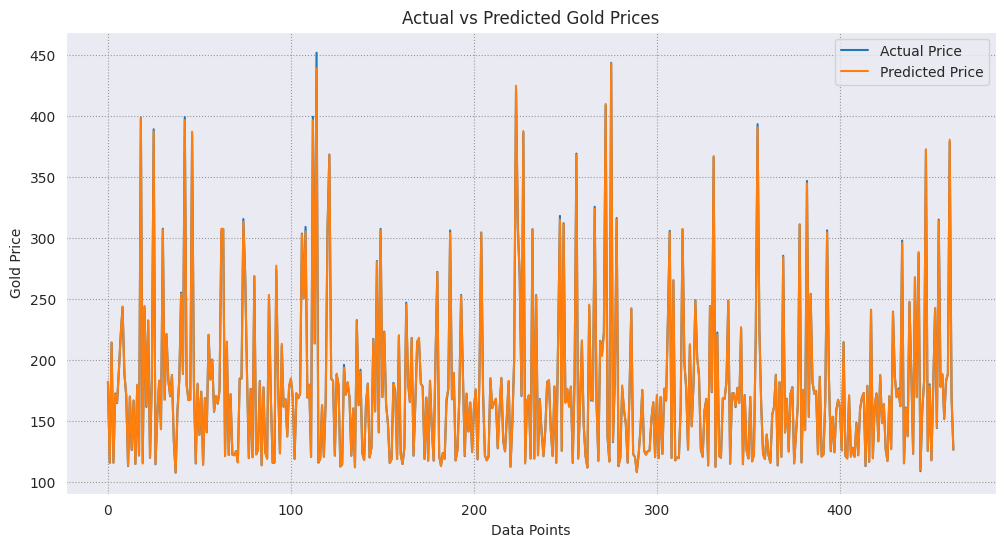


Future Predicted Gold Price :
439.48550292699986


In [ ]:
# =====================================================
# GOLD PRICE ANALYSIS AND PREDICTION PROJECT
# =====================================================

# IMPORT LIBRARIES
# =====================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================
# LOAD DATASET
# =====================================================

df = pd.read_csv("https://raw.githubusercontent.com/sangitaGIT011/Myproj/refs/heads/main/Gold_Price_2016to2026.csv")

# DISPLAY FIRST 5 ROWS
print(df.head())

# =====================================================
# DATA PREPROCESSING
# =====================================================

# CONVERT DATE COLUMN
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# REMOVE MISSING VALUES
df.dropna(inplace=True)

# DISPLAY DATA INFO
print(df.info())

# =====================================================
# GOLD PRICE TREND GRAPH
# =====================================================

plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Close'], linewidth=2)

plt.title("Gold Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

# =====================================================
# HEATMAP
# =====================================================

plt.figure(figsize=(10,6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# =====================================================
# FEATURE SELECTION
# =====================================================

X = df[['Open', 'High', 'Low', 'Volume']]

y = df['Close']

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODEL TRAINING
# =====================================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# PREDICTION
# =====================================================

y_pred = model.predict(X_test)

# DISPLAY FIRST 10 PREDICTIONS
prediction_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nPredicted Gold Prices\n")

print(prediction_df.head(10))

# =====================================================
# ACCURACY SCORE
# =====================================================

r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("\nModel Performance")

print("R2 Score :", r2)

print("Mean Squared Error :", mse)

# =====================================================
# ACTUAL VS PREDICTED GRAPH
# =====================================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    y_pred,
    label='Predicted Price'
)

plt.title("Actual vs Predicted Gold Prices")

plt.xlabel("Data Points")

plt.ylabel("Gold Price")

plt.legend()

plt.grid(True)

plt.show()

# =====================================================
# FUTURE GOLD PRICE PREDICTION
# =====================================================

sample_data = [[3300, 3320, 3280, 120000]]

future_prediction = model.predict(sample_data)

print("\nFuture Predicted Gold Price :")

print(future_prediction[0])

# =====================================================
# END OF PROJECT
# =====================================================